# House-Price Linear Regression

A linear regression workflow using selected housing attributes to predict sale prices.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv('Desktop/houses.csv')
dataset.head()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,BedroomAbvGr,TotRmsAbvGrd,SalePrice
0,1,65.0,8450,7,5,2003,3,8,208500
1,2,80.0,9600,6,8,1976,3,6,181500
2,3,68.0,11250,7,5,2001,3,6,223500
3,4,60.0,9550,7,5,1915,3,7,140000
4,5,84.0,14260,8,5,2000,4,9,250000


In [3]:
for key in dataset.keys():
    print(key)

Id
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
BedroomAbvGr
TotRmsAbvGrd
SalePrice


In [4]:
features = dataset[['LotFrontage', 'LotArea','OverallQual','YearBuilt','BedroomAbvGr','TotRmsAbvGrd']]
targets = dataset['SalePrice']

In [5]:
features

,LotFrontage,LotArea,OverallQual,YearBuilt,BedroomAbvGr,TotRmsAbvGrd
0,65.0,8450,7,2003,3,8
1,80.0,9600,6,1976,3,6
2,68.0,11250,7,2001,3,6
3,60.0,9550,7,1915,3,7
4,84.0,14260,8,2000,4,9
...,...,...,...,...,...,...
1455,62.0,7917,6,1999,3,7
1456,85.0,13175,6,1978,3,7
1457,66.0,9042,7,1941,4,9
1458,68.0,9717,5,1950,2,5


In [6]:
targets

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [7]:
features.isnull().sum()

LotFrontage     259
LotArea           0
OverallQual       0
YearBuilt         0
BedroomAbvGr      0
TotRmsAbvGrd      0
dtype: int64

In [8]:
features = dataset[['LotArea','OverallQual','YearBuilt','BedroomAbvGr','TotRmsAbvGrd']]

In [9]:
features.isnull().sum()

LotArea         0
OverallQual     0
YearBuilt       0
BedroomAbvGr    0
TotRmsAbvGrd    0
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

std_features = pd.DataFrame(scaled_features, columns=features.columns)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    std_features, targets, train_size=0.8, random_state=42)

print(f'Training set size: {len(X_train)}')
print(f'Test set size: {len(X_test)}')

Training set size: 1168
Test set size: 292


In [12]:
regr = linear_model.LinearRegression()

In [13]:
regr.fit(X_train,y_train)

LinearRegression()

In [14]:
print('Coefficients: \n', regr.coef_)

Coefficients: 
 [11480.24245383 42186.28839264 13672.52612278 -9051.0024635
 25718.38050453]


In [15]:
y_pred = regr.predict(X_test)

In [17]:
print('*Current*')
print(y_test[-5:])
print('\n*Prediction*')
print(y_pred[-5:])

*Current*
479      89471
1361    260000
802     189000
651     108000
722     124500
Name: SalePrice, dtype: int64

*Prediction*
[112661.40955024 235671.86963215 226514.45742872  95457.13453764
  87375.46769885]


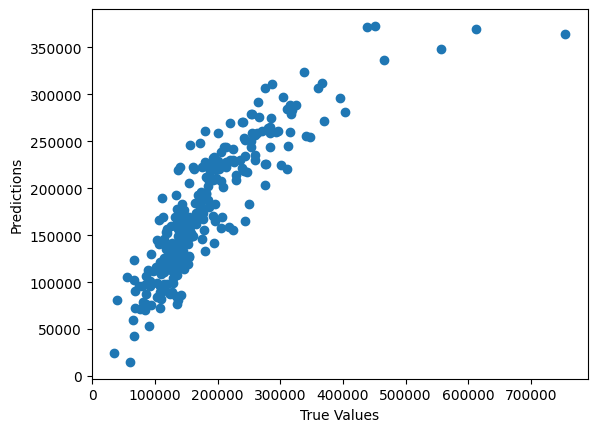

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')

plt.show()

892      6900.094887
1105   -36628.387846
413     -4517.628281
522      7054.817958
1036   -26374.883524
            ...     
479     23190.409550
1361   -24328.130368
802     37514.457429
651    -12542.865462
722    -37124.532301
Name: SalePrice, Length: 292, dtype: float64


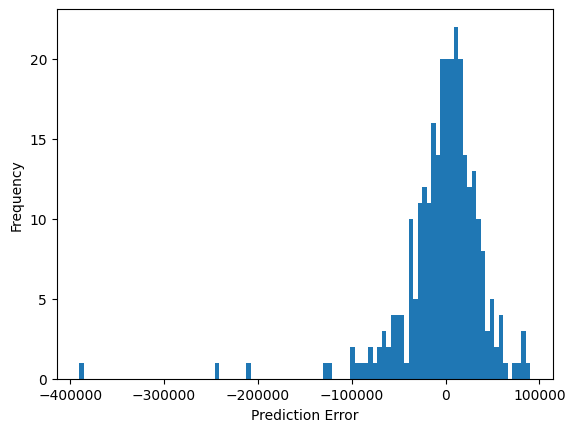

In [20]:
error = y_pred - y_test
print(error)
plt.hist(error, bins=100)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.show()

In [21]:
print("Root mean squared error: %.2f"
     % np.sqrt(mean_squared_error(y_test, y_pred)))

Root mean squared error: 45025.19


In [22]:
print("R^2 score: %.2f" % r2_score(y_test,y_pred))

R^2 score: 0.74
